In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-data-cleaning-analysis-and-visualization/netflix1.csv


In [2]:
df = pd.read_csv('/kaggle/input/netflix-data-cleaning-analysis-and-visualization/netflix1.csv')

In [3]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.shape

(8790, 10)

In [7]:
categorical=['type','country','release_year','rating']

In [8]:
df.drop(columns="show_id", inplace=True)

In [9]:
for i in categorical:
    print(i)
    print(df[i].unique())
    print('_'* 50)

type
['Movie' 'TV Show']
__________________________________________________
country
['United States' 'France' 'Brazil' 'United Kingdom' 'India' 'Germany'
 'Pakistan' 'Not Given' 'China' 'South Africa' 'Japan' 'Nigeria' 'Spain'
 'Philippines' 'Australia' 'Argentina' 'Canada' 'Hong Kong' 'Italy'
 'New Zealand' 'Egypt' 'Colombia' 'Mexico' 'Belgium' 'Switzerland'
 'Taiwan' 'Bulgaria' 'Poland' 'South Korea' 'Saudi Arabia' 'Thailand'
 'Indonesia' 'Kuwait' 'Malaysia' 'Vietnam' 'Lebanon' 'Romania' 'Syria'
 'United Arab Emirates' 'Sweden' 'Mauritius' 'Austria' 'Turkey'
 'Czech Republic' 'Cameroon' 'Netherlands' 'Ireland' 'Russia' 'Kenya'
 'Chile' 'Uruguay' 'Bangladesh' 'Portugal' 'Hungary' 'Norway' 'Singapore'
 'Iceland' 'Serbia' 'Namibia' 'Peru' 'Mozambique' 'Ghana' 'Zimbabwe'
 'Israel' 'Finland' 'Denmark' 'Paraguay' 'Cambodia' 'Georgia'
 'Soviet Union' 'Greece' 'West Germany' 'Iran' 'Venezuela' 'Slovenia'
 'Guatemala' 'Jamaica' 'Somalia' 'Croatia' 'Jordan' 'Luxembourg' 'Senegal'
 'Belarus' 'P

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df["date_added"] = pd.to_datetime(df["date_added"])

In [12]:
df_movies=df[df['type'] == 'Movie']
df_tvShow=df[df['type'] == 'TV Show']

<Axes: xlabel='type', ylabel='count'>

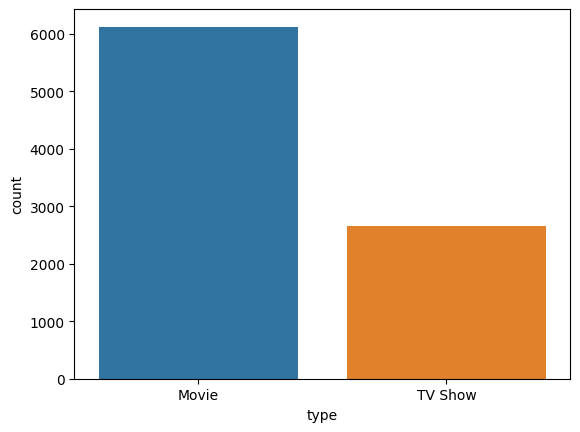

In [13]:
sns.countplot(df, x="type")

<Axes: xlabel='date_added'>

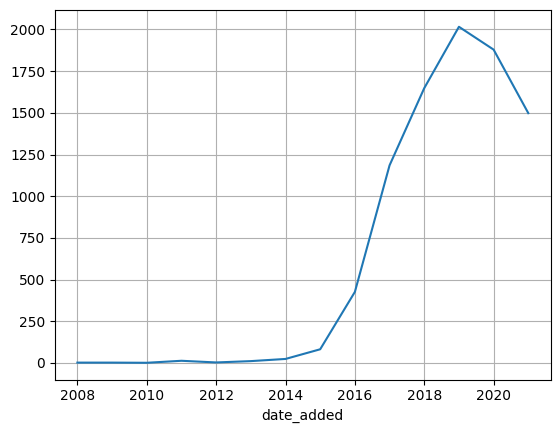

In [14]:
shows_added_via_year = df.groupby(df["date_added"].dt.year)["type"].count()
shows_added_via_year.plot(grid=True)

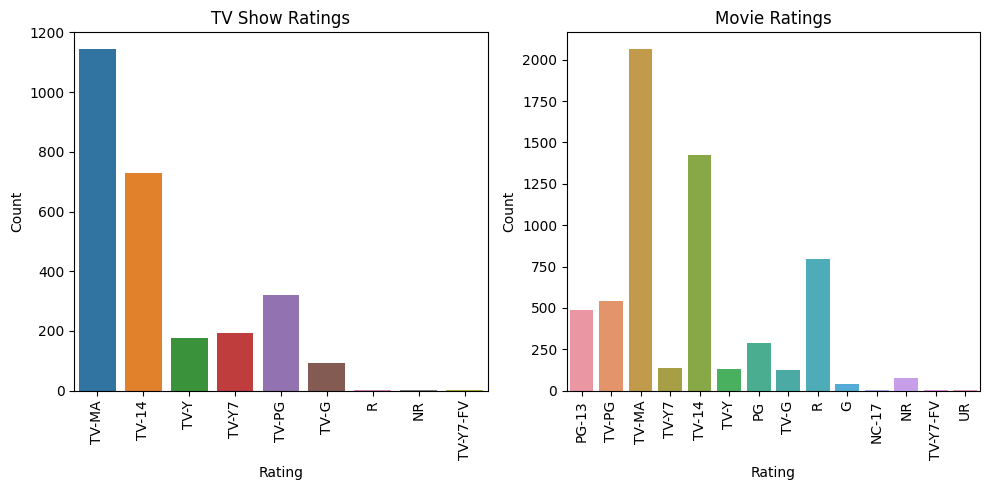

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

#  TV Show ratings
sns.countplot(df_tvShow, x="rating", ax=ax1)
ax1.set_title('TV Show Ratings')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=90)

#  Movie ratings
sns.countplot(df_movies, x="rating", ax=ax2)
ax2.set_title('Movie Ratings')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()

plt.show()


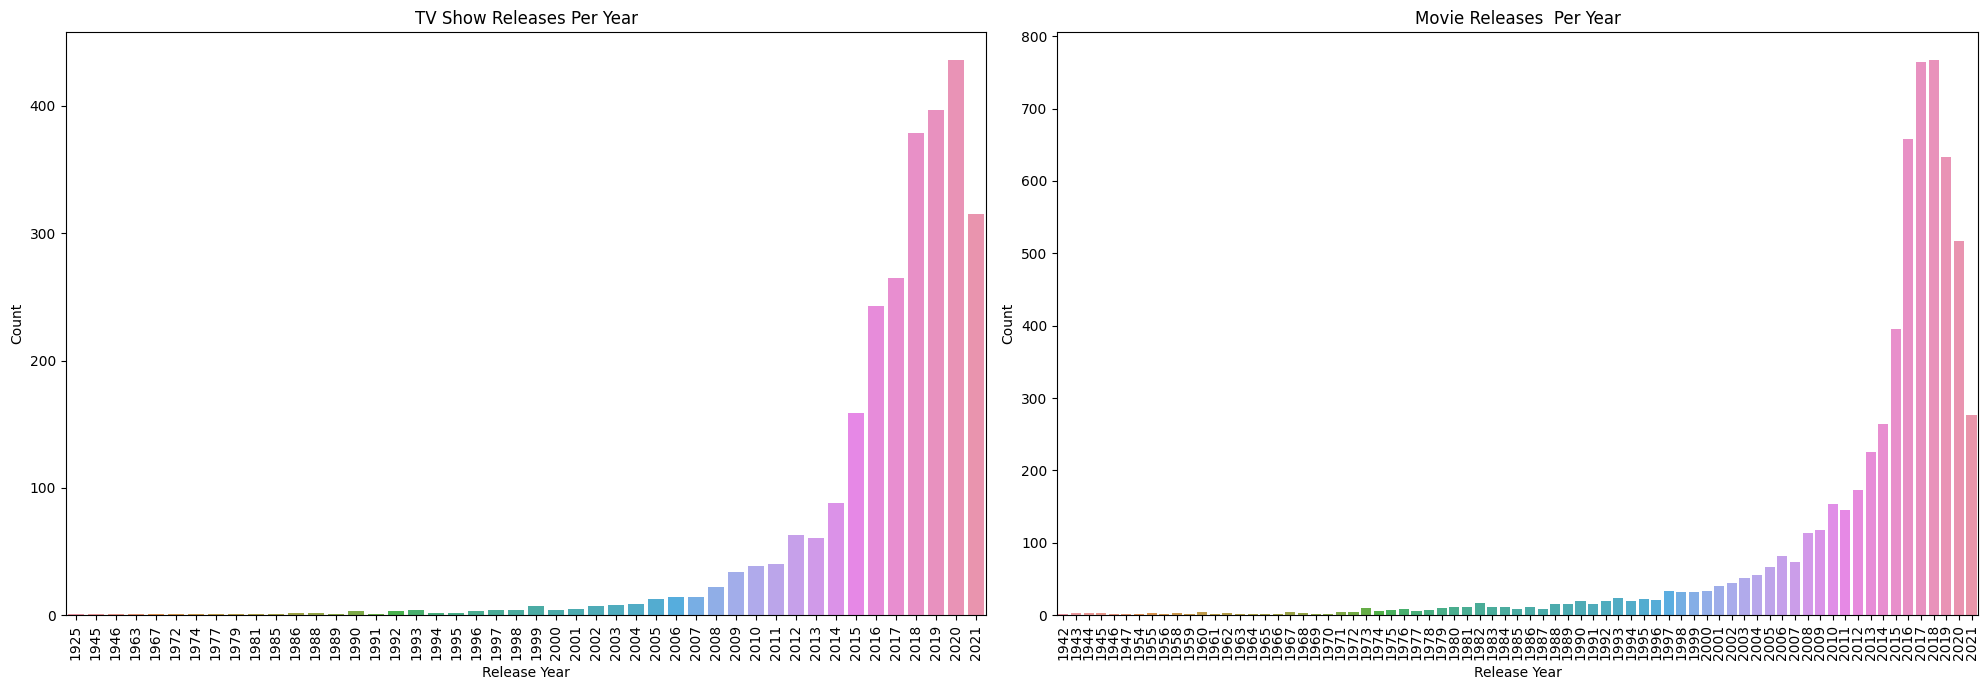

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

#  TV Show ratings
sns.countplot(df_tvShow, x="release_year", ax=ax1)
ax1.set_title('TV Show Releases Per Year')
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=90)

#  Movie ratings
sns.countplot(df_movies, x="release_year", ax=ax2)
ax2.set_title('Movie Releases  Per Year')
ax2.set_xlabel('Release Year')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()

plt.show()

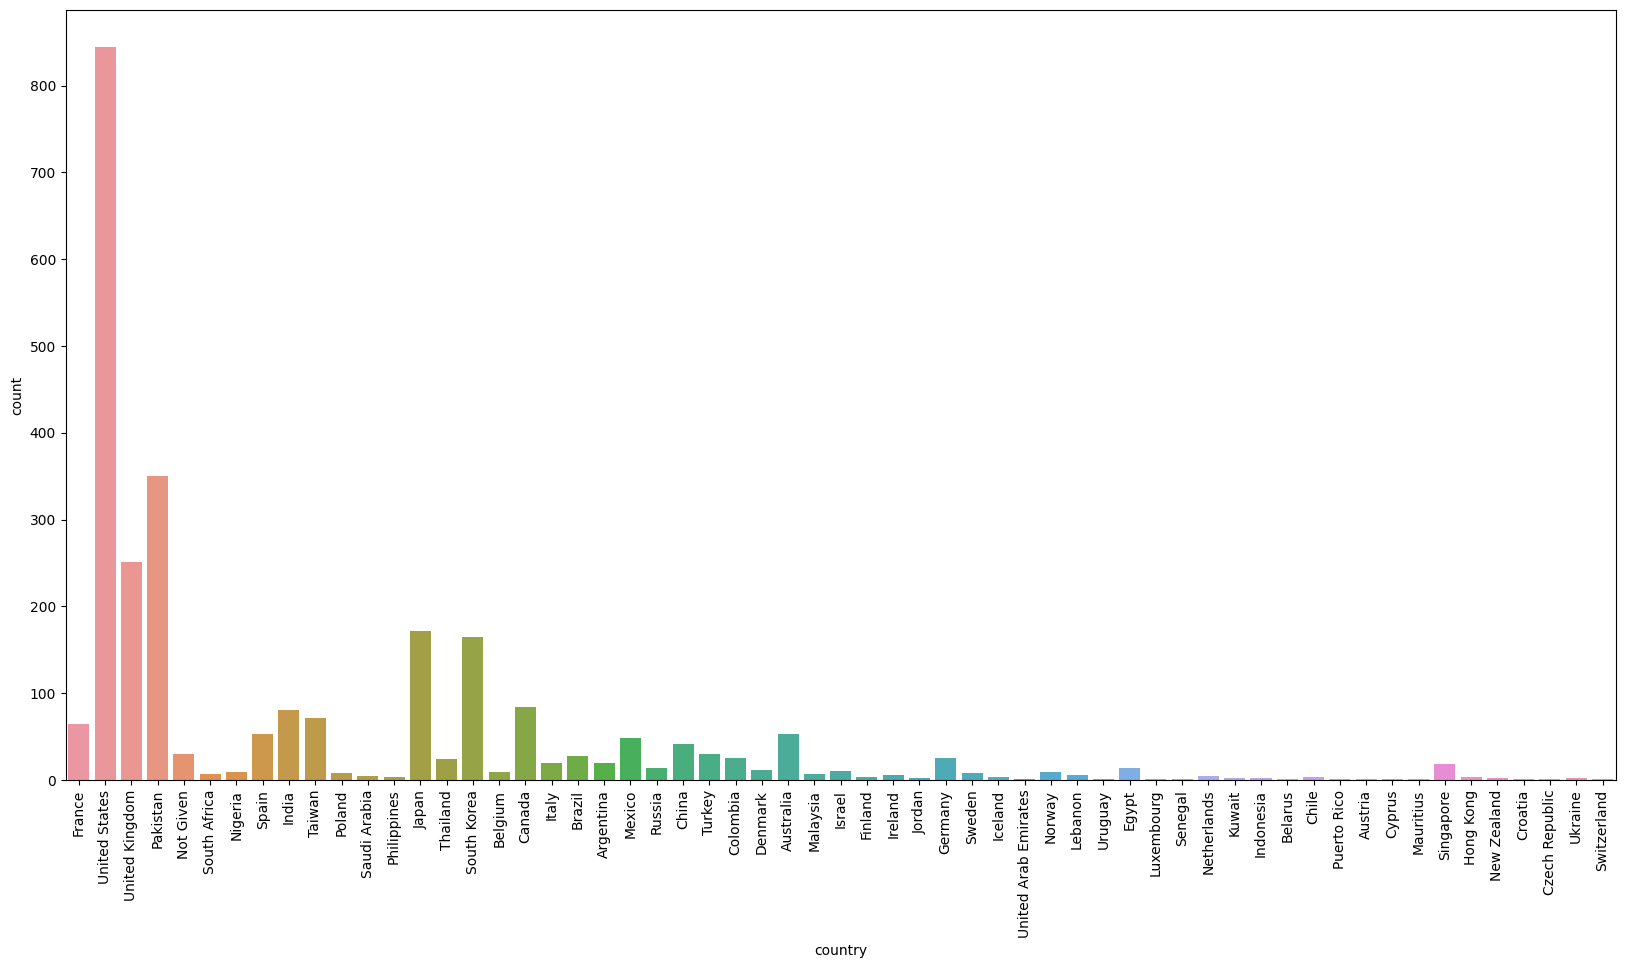

In [17]:
#show released per country 
plt.figure(figsize=(20,10))
sns.countplot(df_tvShow, x="country")
plt.xticks(rotation=90)
plt.show()

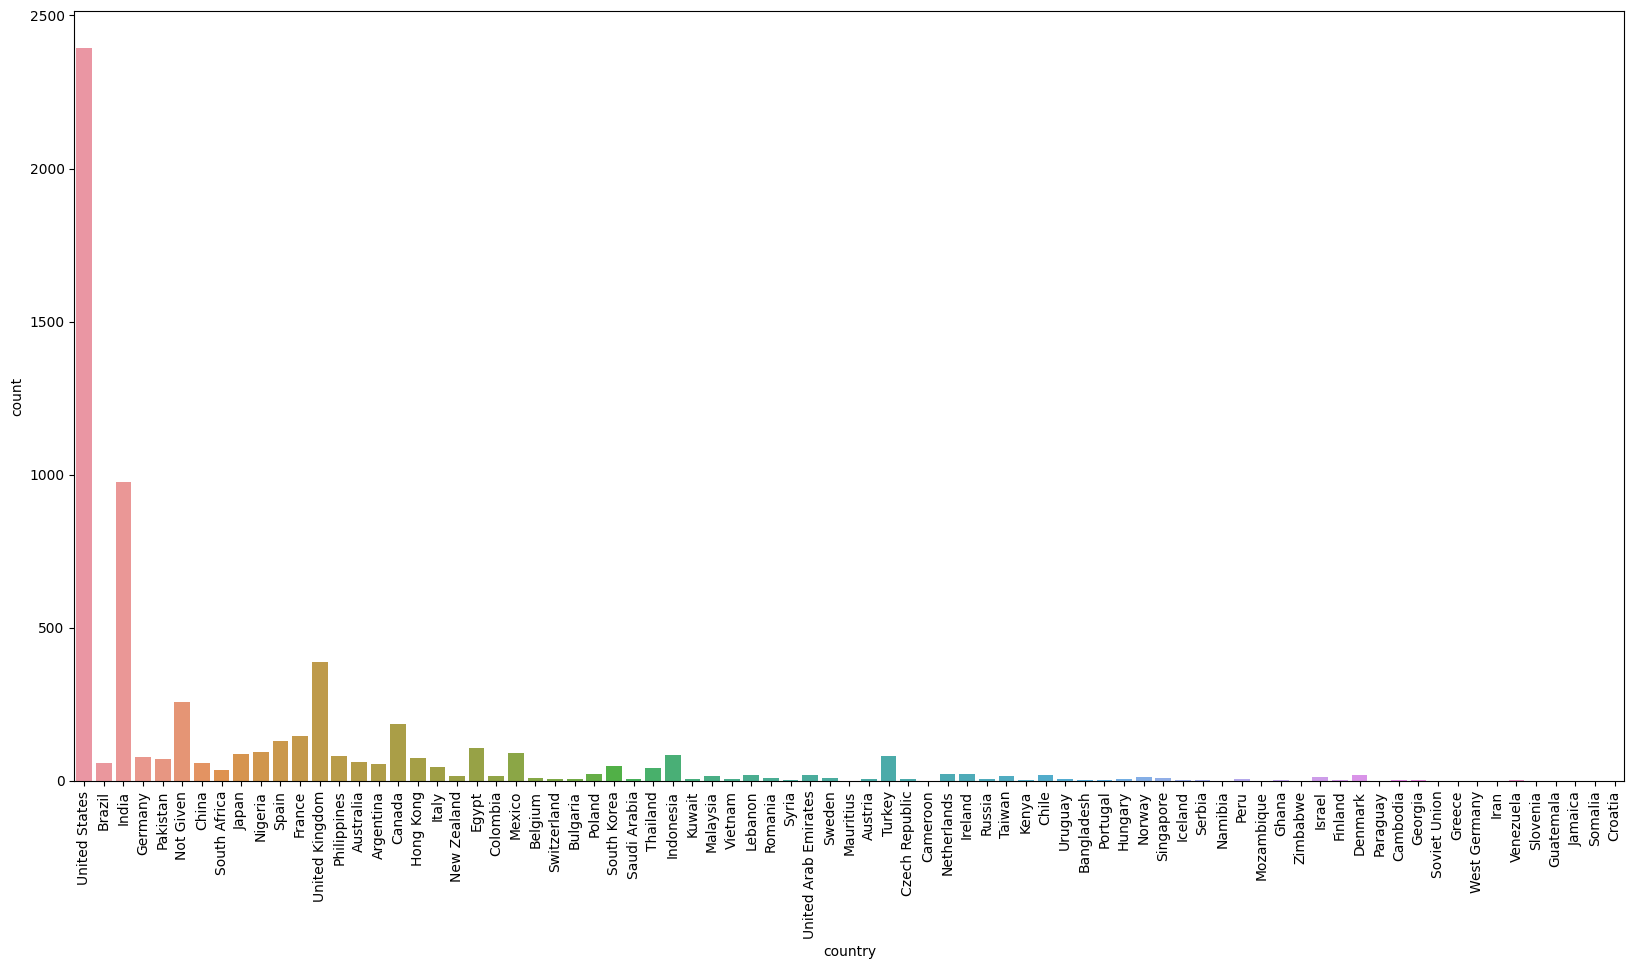

In [18]:
#movies released per country 
plt.figure(figsize=(20,10))
sns.countplot(df_movies, x="country")
plt.xticks(rotation=90)
plt.show()

In [19]:

df_movies["duration_in_min"] = df_movies["duration"].str.split(" ", expand=True)[0].astype(int)
df_movies.head()

/tmp/ipykernel_17/930387422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies["duration_in_min"] = df_movies["duration"].str.split(" ", expand=True)[0].astype(int)


,type,title,director,country,date_added,release_year,rating,duration,listed_in,duration_in_min
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,90
3,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",91
4,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",125
6,Movie,The Starling,Theodore Melfi,United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",104
7,Movie,Motu Patlu in the Game of Zones,Suhas Kadav,India,2021-05-01,2019,TV-Y7,87 min,"Children & Family Movies, Comedies, Music & Mu...",87


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='duration_in_min', ylabel='Count'>

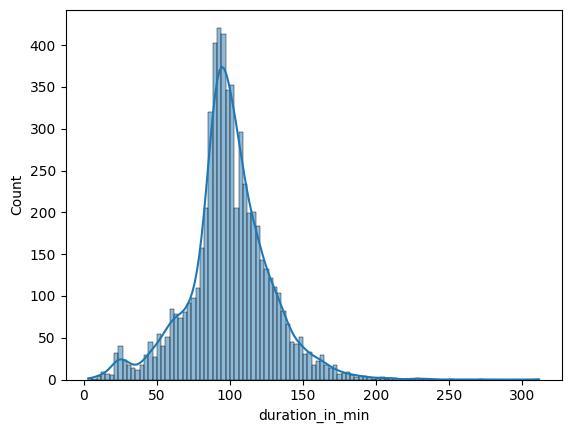

In [20]:
sns.histplot(df_movies['duration_in_min'],kde=True)

In [21]:
df_tvShow["seasons"] = df_tvShow["duration"].str.split(" ", expand=True)[0].astype(int)
df_tvShow

/tmp/ipykernel_17/3528150579.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvShow["seasons"] = df_tvShow["duration"].str.split(" ", expand=True)[0].astype(int)


,type,title,director,country,date_added,release_year,rating,duration,listed_in,seasons
1,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1
2,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",1
5,TV Show,The Great British Baking Show,Andy Devonshire,United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",9
17,TV Show,Jailbirds New Orleans,Not Given,Pakistan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",1
18,TV Show,Crime Stories: India Detectives,Not Given,Pakistan,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",1
...,...,...,...,...,...,...,...,...,...,...
8785,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas",2
8786,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV,3
8787,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",1
8788,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV,1


<Axes: xlabel='seasons', ylabel='count'>

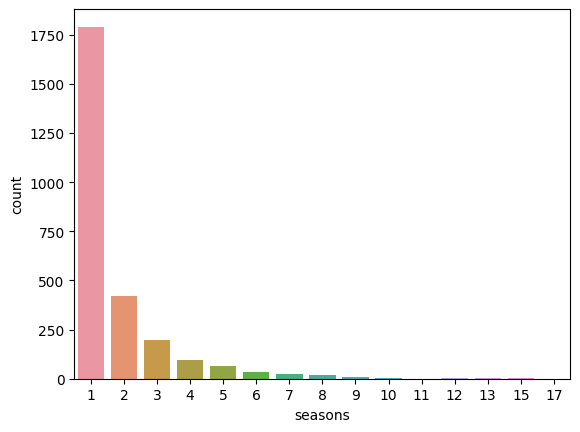

In [22]:
sns.countplot(df_tvShow,x="seasons")

In [23]:
df

,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...
8785,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV
8787,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV


<Axes: ylabel='listed_in'>

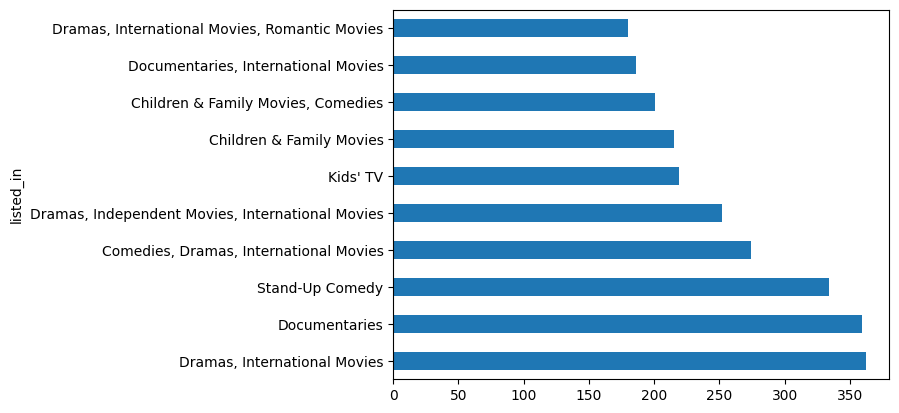

In [24]:
df['listed_in'].value_counts().head(10).plot(kind='barh')